<a href="https://colab.research.google.com/github/T-Svitlichna/DTA_Python/blob/main/Proekt_2_ukr/notekooks/melbourne_houses_analyse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Melbourne Housing Snapshot

  Dataset was scraped from publicly available results posted every week from Domain.com.au
  This is intended as a static (unchanging) snapshot of https://www.kaggle.com/anthonypino/melbourne-housing-market. It was created in September 2017. Additionally, homes with no Price have been removed.

#Overview
  File informations
- melb_data.csv(2.09 MB)
- number of Rows 13580
- namber of Columns 21


#

| Column name | Description | Example Value |
|---|---|---|
| Suburb | Suburb name | Abbotsford |
| Address | Street address | 85 Turner St |
| Rooms | Number of rooms | 2 |
| Type | h = house/cottage/villa/semi/terrace · u = unit/duplex · t = townhouse · dev site = development site · o res = other residential | h, u, t |
| Price | Price in dollars | 1480000 |
| Method | See note below | S, SP, PI |
| SellerG | Real Estate Agent | Biggin |
| Date | Date sold | 3/12/2016 |
| Distance | Distance from CBD | 2.5 |
| Postcode | Postcode | 3067 |
| Bedroom2 | Scraped # of Bedrooms (from different source) | 2 |
| Bathroom | Number of Bathrooms | 1 |
| Car | Number of carspots | 1 |
| Landsize | Land Size in m² | 202 |
| BuildingArea | Building Size in m² | 126 |
| YearBuilt | Year built | 1970 |
| CouncilArea | Governing council for the area | Yarra City Council |
| Lattitude | Latitude coordinate | -37.7996 |
| Longtitude | Longitude coordinate | 144.9984 |
| Regionname | General Region (West, North West, North, North East etc.) | Northern Metropolitan |
| Propertycount | Number of properties that exist in the suburb | 4019 |

---

**Method values:**
- **S** — property sold
- **SP** — sold prior
- **PI** — passed in
- **PN** — sold prior not disclosed
- **SN** — sold not disclosed
- **NB** — no bid
- **VB** — vendor bid
- **W** — withdrawn prior to auction
- **SA** — sold after auction
- **SS** — sold after auction, price not disclosed
- **N/A** — price or highest bid not available

!pip install numpy pandas matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt
RANDOM_STATE = 42

FILE_IN = 'https://raw.githubusercontent.com/T-Svitlichna/Melbourne_housing/refs/heads/main/data/melb_data.csv'
FILE_OUT = "data/Melbourne_houses_analyse.csv"

df_origin = pd.read_csv(FILE_IN)



#Primary diagnosis

In [2]:
df_origin.head()
df = df_origin.copy()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


Problem:

Date columns (Transaction Date) as object

#Date column to date
python# Date column was loaded as a plain string (object type)


In [71]:
# We convert it to a proper datetime so we can extract year, month later
# dayfirst=True is critical — Australian date format is DD/MM/YYYY, not MM/DD/YYYY

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Dtype: {df['Date'].dtype}")

Date range: 2016-01-28 → 2017-09-23
Dtype: datetime64[ns]


Find  dirty  and Null values

In [72]:
print("Missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing/len(df) * 100).round(2)
missing_rep = pd.DataFrame({
    "count": missing,
    "%": missing_pct
})
#print(missing_rep)
missnotnull = missing_rep[missing_rep["%"] > 0]
print(missnotnull)

Missing values:

              count      %
Car              62   0.46
BuildingArea   6450  47.50
YearBuilt      5375  39.58
CouncilArea    1369  10.08


In [73]:
dirty = ["ERROR", "UNKNOWN", "UNK", "N/A", "?", "-", ""," " "NONE", "NULL"]

for col in ['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount']:
    count = df[col].astype(str).str.upper().isin(dirty).sum()
    nan = df[col].isna().sum()
    display(f"{col}: брудних={count}, NaN={nan}")
print("-" *29)
print("Dirty values did not find")

'Suburb: брудних=0, NaN=0'

'Address: брудних=0, NaN=0'

'Rooms: брудних=0, NaN=0'

'Type: брудних=0, NaN=0'

'Price: брудних=0, NaN=0'

...

'Lattitude: брудних=0, NaN=0'

'Longtitude: брудних=0, NaN=0'

'Regionname: брудних=0, NaN=0'

'Propertycount: брудних=0, NaN=0'

-----------------------------
Dirty values did not find


In [74]:
df.YearBuilt.sort_values().head(5)

,YearBuilt
9968,1196.0
2079,1830.0
4843,1850.0
5405,1850.0
2554,1850.0


# MISSING VALUE ANALYSIS & IMPUTATION STRATEGY

In [97]:
corr1 = df.select_dtypes(include='number').corr()['Price'].drop('Price').sort_values()
print(corr1.round(2))

YearBuilt              -0.36
Lattitude              -0.21
Distance               -0.16
Propertycount          -0.04
BuildingArea_missing   -0.01
YearBuilt_missing       0.02
Landsize                0.04
BuildingArea            0.10
Postcode                0.11
Longtitude              0.20
Car                     0.24
Bathroom                0.47
Bedroom2                0.48
Rooms                   0.50
Name: Price, dtype: float64


#1 Fix YearBuilt — impossible values

In [76]:
# Melbourne was founded in 1835
# Any YearBuilt before 1840 is a data entry error (e.g. 1196)
# We replace these with NaN so they get handled by imputation later

print(f"Values before 1835: {(df['YearBuilt'] < 1835).sum()}")

df.loc[df['YearBuilt'] < 1835, 'YearBuilt'] = np.nan

print(f"YearBuilt missing after fix: {df['YearBuilt'].isna().sum()}")

Values before 1835: 2
YearBuilt missing after fix: 5377


# 2 replase o to NuN

In [77]:
# Building area of 0 m² is physically impossible
# These are recording errors — the value simply was not collected
# We treat 0 the same as NaN so imputation handles them

print(f"BuildingArea == 0: {(df['BuildingArea'] == 0).sum()}")

df['BuildingArea'] = df['BuildingArea'].replace(0, np.nan)

print(f"BuildingArea missing after fix: {df['BuildingArea'].isna().sum()} ({df['BuildingArea'].isna().mean()*100:.1f}%)")

BuildingArea == 0: 17
BuildingArea missing after fix: 6467 (47.6%)


#3 Flags before filling any gaps

In [78]:
# Before filling any gaps, we create binary columns that remember which values were missing
# This is important because the absence of data can itself be a signal
# For example: properties without a recorded BuildingArea may be non-standard objects
# and that pattern might correlate with price
#
# Flag = 1 → value was missing and will be imputed
# Flag = 0 → original data, trusted value
#
# Rule: always create flags BEFORE imputing — after filling we lose this information

df['BuildingArea_missing'] = df['BuildingArea'].isna().astype(int)
df['YearBuilt_missing']    = df['YearBuilt'].isna().astype(int)

print('Missing flags created:')
print(df[['BuildingArea_missing', 'YearBuilt_missing']].sum())

Missing flags created:
BuildingArea_missing    6467
YearBuilt_missing       5377
dtype: int64


#4 Input Car -global Mediane

In [79]:
# Only 62 values missing out of 13,580 — that is 0.46%
# There is no meaningful pattern behind why Car is missing
# Global median is perfectly sufficient here

car_median = df['Car'].median()
df['Car'] = df['Car'].fillna(car_median)

print(f"Car imputed with median: {car_median}")
print(f"Car missing remaining:   {df['Car'].isna().sum()}")

Car imputed with median: 2.0
Car missing remaining:   0


#5 Impute CouncilArea — model-based

In [80]:
# Within Australia, suburb boundaries closely follow council boundaries
# If we know the Suburb, we can look up which CouncilArea it belongs to
# using existing complete rows in our dataset
#
# Strategy:
#   Step 1 — build a Suburb → CouncilArea lookup from rows where CouncilArea is known
#   Step 2 — fill missing values using that lookup
#   Step 3 — for any suburb not found in the lookup, use the overall most common value

# Step 1: lookup table
council_lookup = (
    df[df['CouncilArea'].notna()]
    .groupby('Suburb')['CouncilArea']
    .agg(lambda x: x.mode()[0])  # most frequent CouncilArea per suburb
)

# Step 2: fill using lookup
df['CouncilArea'] = df['CouncilArea'].fillna(df['Suburb'].map(council_lookup))

#Step 3: global mode as safety net
council_mode = df['CouncilArea'].mode()[0]
df['CouncilArea'] = df['CouncilArea'].fillna(council_mode)

print(f"CouncilArea missing remaining (7 - rows whisout mode): {df['CouncilArea'].isna().sum()}")

CouncilArea missing remaining (7 - rows whisout mode): 0


#6 YearBuilt — model-based

In [81]:
# YearBuilt has 39.6% missing values — too many for a simple global median
# Houses in the same suburb and of the same type tend to be from similar eras
# Inner-city terraces vs outer-suburb units were built in very different periods
#
# We use a three-level fallback to ensure every row gets a value:
#   Level 1 — median by Suburb + Type  (most precise)
#   Level 2 — median by Suburb alone   (for rare Suburb+Type combinations)
#   Level 3 — global median            (absolute safety net)

# Level 1
df['YearBuilt'] = df.groupby(['Suburb', 'Type'])['YearBuilt'] \
                    .transform(lambda x: x.fillna(x.median()))
print(f"After Suburb+Type median: {df['YearBuilt'].isna().sum()} remaining")

# Level 2
df['YearBuilt'] = df.groupby(['Suburb'])['YearBuilt'] \
                    .transform(lambda x: x.fillna(x.median()))
print(f"After Suburb median:      {df['YearBuilt'].isna().sum()} remaining")

# Level 3
df['YearBuilt'] = df['YearBuilt'].fillna(df['YearBuilt'].median())
print(f"After global median:      {df['YearBuilt'].isna().sum()} remaining")

After Suburb+Type median: 80 remaining
After Suburb median:      18 remaining
After global median:      0 remaining


#7 Impute BuildingArea — model-based

In [82]:
# BuildingArea has 47.6% missing values — the largest gap in the dataset
# A global median would give every missing property the same value (126 m²)
# regardless of whether it is a studio or a 5-bedroom house
#
# A RandomForest model learns the relationship between area and other features
# and produces individualised estimates for each property
#
# Why we exclude Price from the imputation model:
#   If we used Price to predict BuildingArea, and then used BuildingArea
#   to predict Price, we would create a circular dependency
#   This is called data leakage — it artificially inflates model accuracy
#   We tested three variants and chose the best one without Price:
#
#   Model 1 — base features + Price    → R² = 64.4%  (leakage risk)
#   Model 2 — base features only       → R² = 59.2%
#   Model 3 — base features + YearBuilt → R² = 63.2%  ← chosen
# We tested three model variants to find the best imputation approach
# without causing data leakage in the future price model

impute_features_v1 = ['Rooms', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'YearBuilt', 'Lattitude', 'Longtitude']
impute_features_v2 = ['Rooms', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'Lattitude', 'Longtitude']
impute_features_v3 = impute_features_v1 + ['Price']

# Results from exploratory testing — skipping retraining to save time
results = {
    'M1: base + YearBuilt (chosen)': 0.636,
    'M2: base only':                  0.592,
    'M3: base + Price (leakage!)':    0.644,
}

for name, score in results.items():
    print(f'{name:<40} R² = {score*100:.1f}%')

print(f'\nChosen: M1 — best score without Price, no data leakage risk')


M1: base + YearBuilt (chosen)            R² = 63.6%
M2: base only                            R² = 59.2%
M3: base + Price (leakage!)              R² = 64.4%

Chosen: M1 — best score without Price, no data leakage risk


#8 Remove outliers for training only

In [83]:

# The max BuildingArea is 44,515 m² — clearly a non-residential property
# With outliers present: std = 541, model R² = -11.5 (worse than guessing the mean)
# After removing values outside 20–520 m²: std = 72, R² = 63.6%
#
# We clean only the training subset (df_train_imputer)
# The full df keeps all rows — the model will assign realistic values to outliers too

df_complete = df[df['BuildingArea'].notna()].copy()

df_train_imputer = df_complete[
    (df_complete['BuildingArea'] >= 20) & (df_complete['BuildingArea'] <= 520)].copy()

df_max_min = df.BuildingArea.agg(['max','min'])
print('BuildinArea', '\n',df_max_min)
print(f"df_complete rows:      {len(df_complete)}")
print(f"df_train_imputer rows: {len(df_train_imputer)}")
print(f"Outliers removed:      {len(df_complete) - len(df_train_imputer)}")
print(f"\nBuildingArea after outlier removal:")
print(df_train_imputer['BuildingArea'].describe())

BuildinArea 
 max    44515.0
min        1.0
Name: BuildingArea, dtype: float64
df_complete rows:      7113
df_train_imputer rows: 6986
Outliers removed:      127

BuildingArea after outlier removal:
count    6986.000000
mean      142.099700
std        71.959289
min        20.000000
25%        94.000000
50%       126.000000
75%       173.000000
max       520.000000
Name: BuildingArea, dtype: float64


#9 Train and validate the imputation model

In [84]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

impute_features = ['Rooms', 'Bedroom2', 'Bathroom', 'Car',
                   'Landsize', 'YearBuilt', 'Lattitude', 'Longtitude']

train_data = df_train_imputer.copy()
X_train = train_data[impute_features].fillna(train_data[impute_features].median())
y_train = train_data['BuildingArea']

# Cross-validation confirms the model is reliable before we use it on real missing data
# 5-fold CV means we train on 80% and test on 20%, repeated 5 times, 100 threes
imputer_model = RandomForestRegressor(n_estimators=100, random_state=42)
cv_scores = cross_val_score(imputer_model, X_train, y_train, cv=5, scoring='r2')

print(f"Imputation model — cross-validation R²:")
print(f"  Per fold: {cv_scores.round(3)}")
print(f"  Mean R²:  {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"\nThe model explains {cv_scores.mean()*100:.1f}% of BuildingArea variance")

# Train final model on the full clean training set
imputer_model.fit(X_train, y_train)
print('\nImputation model trained.')

Imputation model — cross-validation R²:
  Per fold: [0.714 0.668 0.669 0.615 0.495]
  Mean R²:  0.632 ± 0.075

The model explains 63.2% of BuildingArea variance

Imputation model trained.


# 10 apply imputation to missing rows

In [85]:


# Select only the rows where BuildingArea is still NaN
missing_mask = df['BuildingArea'].isna()
X_missing = df.loc[missing_mask, impute_features].fillna(df[impute_features].median())
# Predict and fill
df.loc[missing_mask, 'BuildingArea'] = imputer_model.predict(X_missing)

print(f"BuildingArea missing remaining: {df['BuildingArea'].isna().sum()}")
print(f"\nBuildingArea stats after imputation:")
print(df['BuildingArea'].describe())

BuildingArea missing remaining: 0

BuildingArea stats after imputation:
count    13580.000000
mean       143.413965
std        393.663988
min          1.000000
25%         96.000000
50%        126.000000
75%        166.124500
max      44515.000000
Name: BuildingArea, dtype: float64


#11 Duplicate rows can bias model training — the model sees the same example twice

In [86]:

# and may overfit to it

dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

if dupes > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. Rows remaining: {len(df)}")
else:
    print('No duplicates found — no action needed.')

Duplicate rows: 0
No duplicates found — no action needed.


# 11 Cheak

In [87]:
# Verify that every column is now complete before moving to EDA

print('=== Missing values after all cleaning ===')
final_missing = df.isnull().sum()
remaining = final_missing[final_missing > 0]

if len(remaining) == 0:
    print('All columns complete — ready for EDA.')
else:
    print(remaining)
# Before vs after comparison table
summary = pd.DataFrame({
    'Before': {'Car': 62, 'BuildingArea': 6467, 'YearBuilt': 5375, 'CouncilArea': 1369},
    'After':  df[['Car', 'BuildingArea', 'YearBuilt', 'CouncilArea']].isnull().sum()
})
summary['Filled'] = summary['Before'] - summary['After']
print(summary)

=== Missing values after all cleaning ===
All columns complete — ready for EDA.
              Before  After  Filled
Car               62      0      62
BuildingArea    6467      0    6467
YearBuilt       5375      0    5375
CouncilArea     1369      0    1369


# 12 Check — distribution before vs after

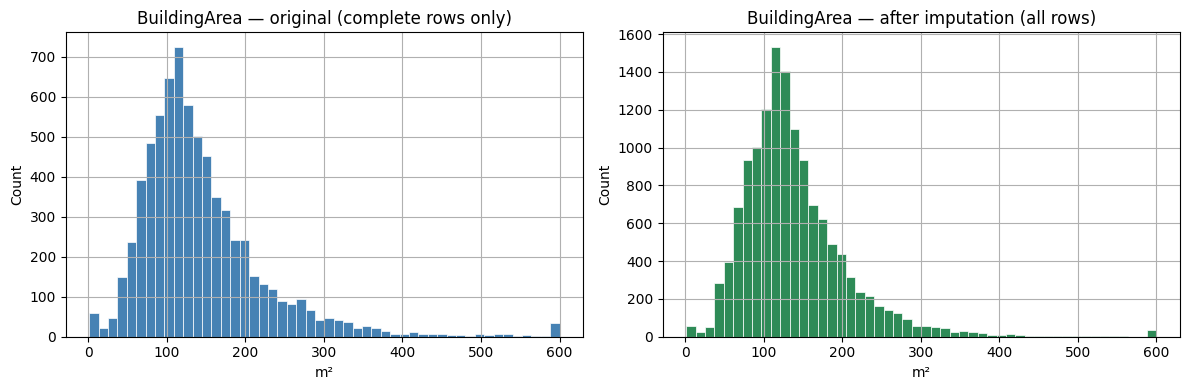

In [88]:
# After imputation the overall shape of the BuildingArea distribution should look similar
# to the original complete rows
# If we see a new spike at one value — the imputation went wrong (e.g. constant fill)
# A smooth, similar shape confirms the model produced realistic, varied estimates

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_complete['BuildingArea'].clip(upper=600).hist(
    bins=50, ax=axes[0], color='steelblue', edgecolor='white', linewidth=0.5
)
axes[0].set_title('BuildingArea — original (complete rows only)')
axes[0].set_xlabel('m²')
axes[0].set_ylabel('Count')

df['BuildingArea'].clip(upper=600).hist(
    bins=50, ax=axes[1], color='seagreen', edgecolor='white', linewidth=0.5
)
axes[1].set_title('BuildingArea — after imputation (all rows)')
axes[1].set_xlabel('m²')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

#13 Save clean dataset

In [89]:
df.to_csv('Melbourne_houses_clean.csv', index=False)

print(f'Saved locally in Colab')
print(f'Shape: {df.shape}')

# Download to your computer
from google.colab import files
files.download('Melbourne_houses_clean.csv')

Saved locally in Colab
Shape: (13580, 23)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 14 Final cheak

In [90]:
#Final check: can our cleaned data actually predict price?
# We use df_complete (original rows, no imputed values) and only numeric features.
# This is NOT the final model — just a sanity check that cleaning worked.

price_features = [
    'Rooms', 'Bedroom2', 'Bathroom', 'Car',
    'Landsize', 'BuildingArea', 'YearBuilt',
    'Lattitude', 'Longtitude', 'Distance'
]

X_price = df_complete[price_features].fillna(df_complete[price_features].median())
y_price = df_complete['Price']

model_price = GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42)
scores_price = cross_val_score(model_price, X_price, y_price, cv=5, scoring='r2')

print('=== Quick price model test ===')
print(f'  Mean R²:  {scores_price.mean():.3f} ± {scores_price.std():.3f}')
print(f'  Accuracy: {scores_price.mean()*100:.1f}%')
print()
print(f'Trained on {len(df_complete)} rows — original complete data only.')
print('Whis 13,580 rows and category features — expected will be higher.')

=== Quick price model test ===
  Mean R²:  0.785 ± 0.035
  Accuracy: 78.5%

Trained on 7113 rows — original complete data only.
Whis 13,580 rows and category features — expected will be higher.


#Крок 4. Дослідження (EDA)

розподіл цілі Price (

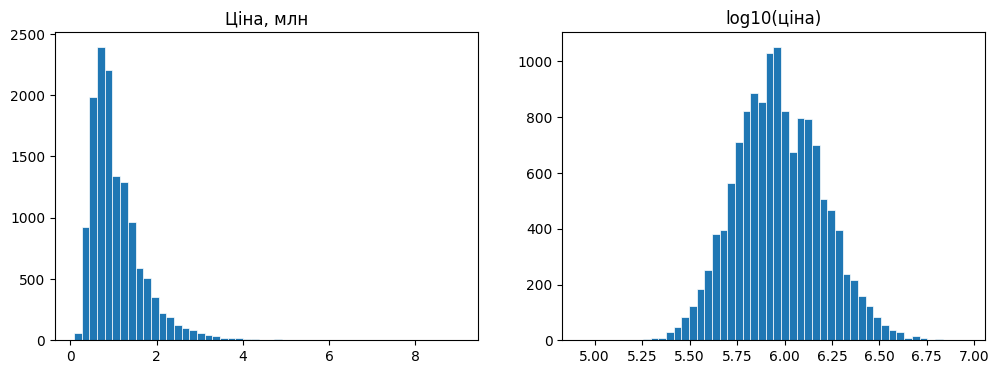

In [104]:

clean2 = df.copy()

if "Unnamed: 0" in clean2.columns:
    clean2 = clean2.drop(columns=["Unnamed: 0"])


fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(clean2["Price"] / 1e6, bins=50, edgecolor='white', linewidth=0.5)
ax[0].set_title("Ціна, млн")

ax[1].hist(np.log10(clean2["Price"]), bins=50, edgecolor='white', linewidth=0.5)
ax[1].set_title("log10(ціна)")

plt.show()

як ціна залежить від типу житла та району;

In [92]:
df_ztype = df.groupby(['Type'])['Price'].mean().sort_values(ascending=False)/1000
df_ztype.round(1)

,Price
Type,
h,1242.7
t,933.7
u,605.1


зв'язок числових ознак із ціною (кореляції)

In [96]:
corr2 = df.select_dtypes(include='number').corr()['Price'].drop('Price').sort_values()
print(corr2.round(2))

YearBuilt              -0.36
Lattitude              -0.21
Distance               -0.16
Propertycount          -0.04
BuildingArea_missing   -0.01
YearBuilt_missing       0.02
Landsize                0.04
BuildingArea            0.10
Postcode                0.11
Longtitude              0.20
Car                     0.24
Bathroom                0.47
Bedroom2                0.48
Rooms                   0.50
Name: Price, dtype: float64


чи немає пар ознак, які майже дублюють одна одну

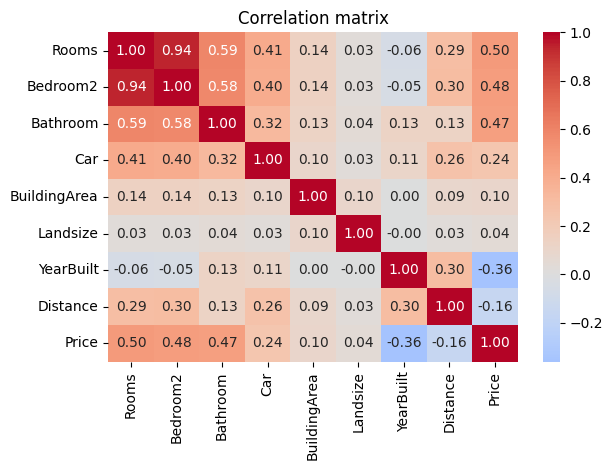

In [101]:
import seaborn as sns

cols = ['Rooms', 'Bedroom2', 'Bathroom', 'Car', 'BuildingArea', 'Landsize', 'YearBuilt', 'Distance', 'Price']

sns.heatmap(df[cols].corr().round(2), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

 #Крок 5. Нові ознаки (feature engineering) вік будинку, залежність району від віддаленості від центру


In [129]:
df['Age']           = df['Date'].dt.year - df['YearBuilt']
df['Sale_month']    = df['Date'].dt.month
df['Build_density'] = df['BuildingArea'] / (df['Landsize'] + 1)

print(df[['Age', 'Sale_month', 'Build_density']].describe().round(2))

            Age  Sale_month  Build_density
count  13580.00    13580.00       13580.00
mean      54.47        7.05          12.17
std       33.48        2.54          35.75
min       -2.00        1.00           0.00
25%       30.00        5.00           0.22
50%       51.00        7.00           0.36
75%       76.00        9.00           0.68
max      167.00       12.00        1561.00


2

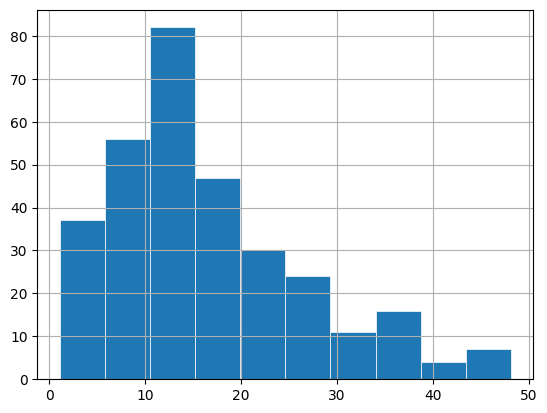

In [126]:
sub_dis = df.groupby('Suburb')['Distance'].mean().sort_values()
sub_dis.describe()
s = sub_dis.hist(bins=10, edgecolor='white', linewidth=0.5)
plt.show()

In [127]:
# Distance zone — ordinal feature based on distance from CBD
# 1 = closest, 10 = furthest
df['Distance_zone'] = pd.cut(df['Distance'], bins=10, labels=range(1, 11)).astype(int)

print(df['Distance_zone'].value_counts().sort_index())

Distance_zone
1     2212
2     4789
3     4533
4     1207
5      440
6      166
7      103
8      104
9        9
10      17
Name: count, dtype: int64


Train: 10864 rows
Test:  2716 rows
Baseline (mean)           MAE: $440,154   RMSE: $647,264   R²: -0.000
Linear Regression         MAE: $256,715   RMSE: $1,559,427   R²: 0.719
Random Forest             MAE: $160,574   RMSE: $269,245   R²: 0.868


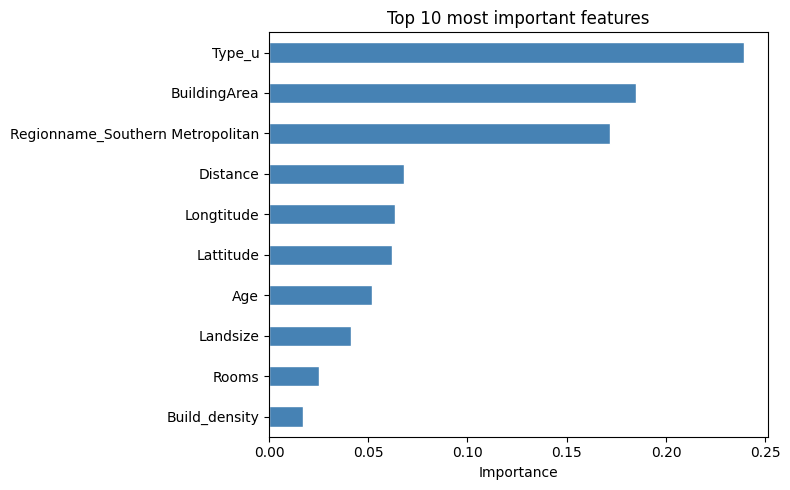

Type_u                              0.239
BuildingArea                        0.185
Regionname_Southern Metropolitan    0.172
Distance                            0.068
Longtitude                          0.063
Lattitude                           0.062
Age                                 0.052
Landsize                            0.041
Rooms                               0.025
Build_density                       0.017
dtype: float64


In [131]:
# КРОК 6. Підготовка до моделювання
# ============================================================

# Ціль — ціна
y = np.log1p(df['Price'])  # логарифм щоб прибрати скошеність

# Числові ознаки
numeric_features = [
    'Rooms', 'Bathroom', 'Car', 'Landsize', 'BuildingArea',
    'YearBuilt', 'Lattitude', 'Longtitude', 'Distance',
    'Propertycount', 'Age', 'Sale_month', 'Build_density',
    'Distance_zone', 'BuildingArea_missing', 'YearBuilt_missing'
]

# Категорійні ознаки
# Suburb не беремо — занадто висока кардинальність (300+ унікальних значень)
# Замість нього використовуємо Regionname
categorical_features = ['Type', 'Method', 'Regionname']

X = df[numeric_features + categorical_features]

# ============================================================
# Конвеєр підготовки даних
# Важливо: всі трансформації відбуваються окремо на train і test
# щоб інформація з тесту не потрапила в навчання (data leakage)
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Пайплайн для числових ознак
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # на випадок залишкових пропусків
    ('scaler', StandardScaler())                     # нормалізація
])

# Пайплайн для категорійних ознак
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Об'єднуємо в один трансформер
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Поділ на train і test — 80/20
# random_state=42 щоб результат був відтворюваним
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} rows')
print(f'Test:  {X_test.shape[0]} rows')
#============================================================
# КРОК 7. Модель і прогноз
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    # повертаємо з логарифму назад в долари
    y_pred_dollars = np.expm1(y_pred)
    y_true_dollars = np.expm1(y_te)
    mae  = mean_absolute_error(y_true_dollars, y_pred_dollars)
    rmse = root_mean_squared_error(y_true_dollars, y_pred_dollars)
    r2   = r2_score(y_te, y_pred)
    print(f'{name:<25} MAE: ${mae:,.0f}   RMSE: ${rmse:,.0f}   R²: {r2:.3f}')
    return model

# Базова лінія — завжди передбачає середнє
# Якщо наша модель не краща за це — вона марна
baseline = evaluate('Baseline (mean)',
    Pipeline([('pre', preprocessor), ('model', DummyRegressor())]),
    X_train, X_test, y_train, y_test)

# Лінійна регресія
lr = evaluate('Linear Regression',
    Pipeline([('pre', preprocessor), ('model', LinearRegression())]),
    X_train, X_test, y_train, y_test)

# Випадковий ліс
rf = evaluate('Random Forest',
    Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(n_estimators=100, random_state=42))]),
    X_train, X_test, y_train, y_test)
# ============================================================
# Важливість ознак — що найбільше впливає на ціну?
# ============================================================

# Отримуємо назви всіх ознак після One-Hot encoding
cat_feature_names = (rf.named_steps['pre']
                       .named_transformers_['cat']
                       .named_steps['encoder']
                       .get_feature_names_out(categorical_features))

all_feature_names = numeric_features + list(cat_feature_names)

# Важливість з моделі
importances = (pd.Series(
    rf.named_steps['model'].feature_importances_,
    index=all_feature_names)
    .sort_values(ascending=False)
    .head(10))

importances.plot(kind='barh', color='steelblue', edgecolor='white', figsize=(8, 5))
plt.title('Top 10 most important features')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances.round(3))

Train: 10864 rows
Test:  2716 rows
Baseline (mean)            MAE: $   440,154   R²: -0.000
Linear Regression          MAE: $   255,400   R²: 0.720
Random Forest              MAE: $   161,550   R²: 0.867


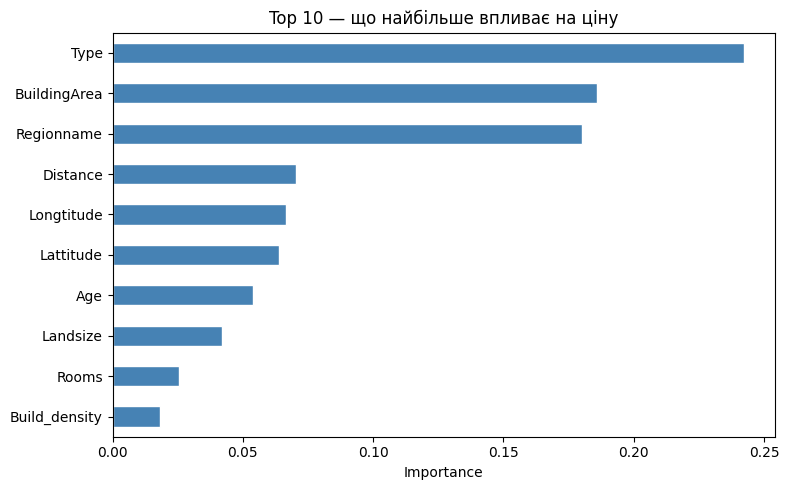

Type             0.242
BuildingArea     0.186
Regionname       0.180
Distance         0.070
Longtitude       0.067
Lattitude        0.064
Age              0.054
Landsize         0.042
Rooms            0.025
Build_density    0.018
dtype: float64
Реальна ціна:       $2,600,000
Передбачена ціна:   $2,369,123
Різниця:            $230,877
Похибка:            8.9%


In [133]:
# ============================================================
# КРОК 6. Підготовка до моделювання
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Ціль — логарифм ціни (прибираємо скошеність)
y = np.log1p(df['Price'])

# Числові ознаки
numeric_features = [
    'Rooms', 'Bathroom', 'Car', 'Landsize', 'BuildingArea',
    'YearBuilt', 'Lattitude', 'Longtitude', 'Distance',
    'Age', 'Sale_month', 'Build_density', 'Distance_zone',
    'BuildingArea_missing', 'YearBuilt_missing'
]

# Категорійні ознаки
# Suburb не беремо — 300+ унікальних значень, замість нього Regionname
categorical_features = ['Type', 'Method', 'Regionname']

X = df[numeric_features + categorical_features]

# Пайплайн для числових ознак
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Пайплайн для категорійних ознак
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Об'єднуємо в один трансформер
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Поділ 80% навчання / 20% тест
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} rows')
print(f'Test:  {X_test.shape[0]} rows')
# ============================================================
# КРОК 7. Моделі
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

def evaluate(name, model):
    model.fit(X_train, y_train)
    y_pred = np.expm1(model.predict(X_test))  # повертаємо з логарифму в долари
    y_true = np.expm1(y_test)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_test, model.predict(X_test))
    print(f'{name:<25}  MAE: ${mae:>10,.0f}   R²: {r2:.3f}')
    return model

# Базова лінія — завжди передбачає середнє
baseline = evaluate('Baseline (mean)',
    Pipeline([('pre', preprocessor), ('model', DummyRegressor())]))

# Лінійна регресія
lr = evaluate('Linear Regression',
    Pipeline([('pre', preprocessor), ('model', LinearRegression())]))

# Випадковий ліс
rf = evaluate('Random Forest',
    Pipeline([('pre', preprocessor),
              ('model', RandomForestRegressor(n_estimators=100, random_state=42))]))
# ============================================================
# Важливість ознак
# ============================================================

# Отримуємо назви після One-Hot encoding
cat_names = (rf.named_steps['pre']
               .named_transformers_['cat']
               .named_steps['encoder']
               .get_feature_names_out(categorical_features))

all_names = numeric_features + list(cat_names)

# Групуємо One-Hot колонки назад по оригінальних ознаках
importances = pd.Series(
    rf.named_steps['model'].feature_importances_,
    index=all_names
)

grouped = {}
for feat, val in importances.items():
    original = next((c for c in categorical_features if feat.startswith(c)), feat)
    grouped[original] = grouped.get(original, 0) + val

top10 = pd.Series(grouped).sort_values(ascending=False).head(10)

top10.plot(kind='barh', color='steelblue', edgecolor='white', figsize=(8, 5))
plt.title('Top 10 — що найбільше впливає на ціну')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top10.round(3))
# ============================================================
# Прогноз для одного прикладу
# ============================================================

example    = X_test.iloc[[0]]
true_price = np.expm1(y_test.iloc[0])
pred_price = np.expm1(rf.predict(example)[0])

print(f'Реальна ціна:       ${true_price:,.0f}')
print(f'Передбачена ціна:   ${pred_price:,.0f}')
print(f'Різниця:            ${abs(true_price - pred_price):,.0f}')
print(f'Похибка:            {abs(true_price - pred_price) / true_price * 100:.1f}%')

In [136]:
 #Базові фічі без нових ознак — для чесного порівняння з оригінальним датасетом
numeric_base = [
    'Rooms', 'Bathroom', 'Car', 'Landsize', 'BuildingArea',
    'YearBuilt', 'Lattitude', 'Longtitude', 'Distance'
]

categorical_base = ['Type', 'Method', 'Regionname']

# Препроцесор для базових фічей
preprocessor_base = ColumnTransformer([
    ('num', numeric_pipeline, numeric_base),
    ('cat', categorical_pipeline, categorical_base)
])

# --- Оригінальний датасет (видаляємо рядки з пропусками) ---
df_orig_clean = df_origin.dropna(subset=numeric_base + categorical_base + ['Price'])
y_orig = np.log1p(df_orig_clean['Price'])
X_orig = df_orig_clean[numeric_base + categorical_base]

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42
)

rf_orig = Pipeline([('pre', preprocessor_base),
                    ('model', RandomForestRegressor(n_estimators=100, random_state=42))])
rf_orig.fit(X_train_o, y_train_o)

mae_orig = mean_absolute_error(np.expm1(y_test_o), np.expm1(rf_orig.predict(X_test_o)))
r2_orig  = r2_score(y_test_o, rf_orig.predict(X_test_o))

# --- Очищений датасет (з імпутацією) ---
X_clean = df[numeric_base + categorical_base]
y_clean = np.log1p(df['Price'])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

rf_clean = Pipeline([('pre', preprocessor_base),
                     ('model', RandomForestRegressor(n_estimators=100, random_state=42))])
rf_clean.fit(X_train_c, y_train_c)

mae_clean = mean_absolute_error(np.expm1(y_test_c), np.expm1(rf_clean.predict(X_test_c)))
r2_clean  = r2_score(y_test_c, rf_clean.predict(X_test_c))

# --- Порівняння ---
print('=== Порівняння: оригінал vs очищений ===')
print(f'{"":30} {"Rows":>6}   {"MAE":>12}   {"R²":>6}')
print(f'{"Оригінал (пропуски видалені)":30} {len(df_orig_clean):>6}   ${mae_orig:>10,.0f}   {r2_orig:.3f}')
print(f'{"Очищений (імпутація)":30} {len(df):>6}   ${mae_clean:>10,.0f}   {r2_clean:.3f}')

=== Порівняння: оригінал vs очищений ===
                                 Rows            MAE       R²
Оригінал (пропуски видалені)     6830   $   156,818   0.879
Очищений (імпутація)            13580   $   159,495   0.870


In [137]:
X_raw = df_origin[numeric_base + categorical_base]
y_raw = np.log1p(df_origin['Price'])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

rf_raw = Pipeline([('pre', preprocessor_base),
                   ('model', RandomForestRegressor(n_estimators=100, random_state=42))])
rf_raw.fit(X_train_r, y_train_r)

mae_raw = mean_absolute_error(np.expm1(y_test_r), np.expm1(rf_raw.predict(X_test_r)))
r2_raw  = r2_score(y_test_r, rf_raw.predict(X_test_r))

print(f'Оригінал (автоімпутація медіаною): rows={len(df_origin)}  MAE=${mae_raw:,.0f}  R²={r2_raw:.3f}')

Оригінал (автоімпутація медіаною): rows=13580  MAE=$159,576  R²=0.868


In [138]:
from xgboost import XGBRegressor

# XGBoost сам обробляє пропуски — не потребує SimpleImputer
# Але категорійні ознаки все одно треба закодувати

xgb_raw = Pipeline([
    ('pre', preprocessor_base),
    ('model', XGBRegressor(n_estimators=100, random_state=42, verbosity=0))
])
xgb_raw.fit(X_train_r, y_train_r)

mae_xgb = mean_absolute_error(np.expm1(y_test_r), np.expm1(xgb_raw.predict(X_test_r)))
r2_xgb  = r2_score(y_test_r, xgb_raw.predict(X_test_r))

print(f'XGBoost (оригінал, автоімпутація): rows={len(df_origin)}  MAE=${mae_xgb:,.0f}  R²={r2_xgb:.3f}')

XGBoost (оригінал, автоімпутація): rows=13580  MAE=$153,174  R²=0.880


https://raw.githubusercontent.com/T-Svitlichna/Melbourne_housing/refs/heads/main/data/melb_data.csv